# Unconstrainted PINning

## Targets generation

In [1]:
import numpy as np
from src.targets_generation import Gaussian_seq

In [2]:
N = 500 # number of neurons
T = 10.5 # sequence length (in seconds)
dt = 0.001 # integration step (in seconds)
sigma = np.sqrt(0.3) # width of the gaussian curve
epsilon = 0.05

In [3]:
gs = Gaussian_seq(T, dt)
targets = gs.target_functions(T, sigma, N, epsilon)

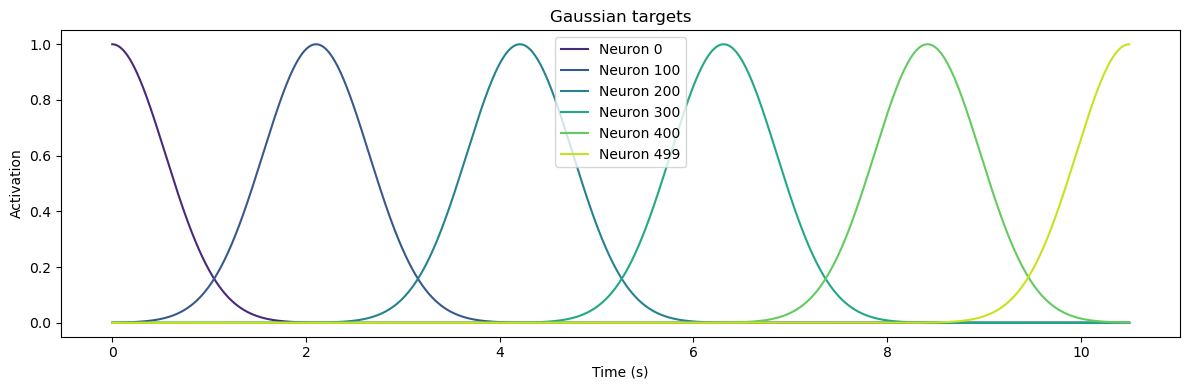

In [8]:
gs.gaussian_graph(T, sigma, N, neuron_list = [0, 100, 200, 300, 400, 499])

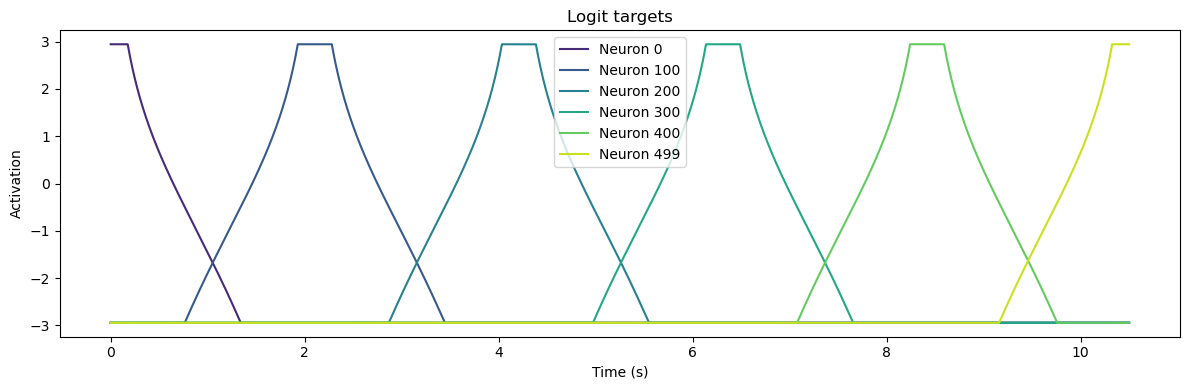

In [9]:
gs.target_graph(T, sigma, N, neuron_list = [0, 100, 200, 300, 400, 499], epsilon=epsilon)

## Inputs generation

In [4]:
from src.inputs_generation import Inputs

In [5]:
WN_tau = 1  # inputs' correlation time (in seconds)
h0 = 0.15 # inputs' scale

In [6]:
ipt = Inputs(T, dt)
inputs = ipt.inputs(N, WN_tau, h0)

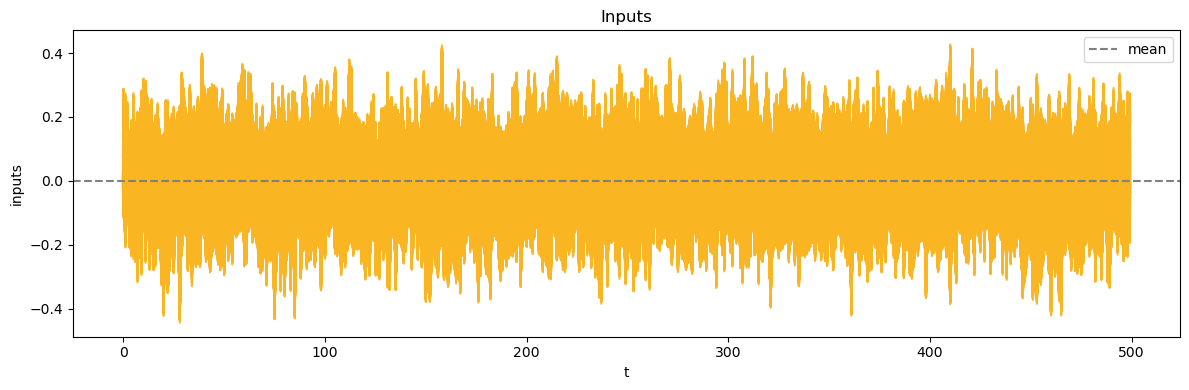

In [9]:
ipt.display_inputs(N, WN_tau, h0)

## Training

In [7]:
from src.training import RNN, PINning

Training parameters, fixed according to Rajan, Harvey & Tank (2016).

In [8]:
p = 0.2 # fraction of plastic synapses in the network
g = 1.5 # chaos parameter in [1.2, 1.5]
tau = 0.01 # membrane time constant (in seconds)
theta = 0 # sigmoid threshold
p0 = 10 # initial P matrix scaling factor: amplitude of 1 to 10 times h0
n_runs = 500 # number of training steps to learn J
n_steps = 50 # number of additionnal steps where J is not modified
cv_threshold = 0.02 # error value at which we deem the model to converge
p_reg = 1e-9 # Ridge regularization parameter

Run 1 | run_error=0.009894 | ||J||=398.18 | Δ||J||=+0.00
Run 2 | run_error=0.010308 | ||J||=466.29 | Δ||J||=+68.11
Run 3 | run_error=0.012259 | ||J||=491.79 | Δ||J||=+25.50
Run 4 | run_error=0.010016 | ||J||=506.37 | Δ||J||=+14.58
Run 5 | run_error=0.008747 | ||J||=522.75 | Δ||J||=+16.38
Run 6 | run_error=0.009167 | ||J||=534.88 | Δ||J||=+12.12
Run 7 | run_error=0.008947 | ||J||=539.91 | Δ||J||=+5.03
Run 8 | run_error=0.008368 | ||J||=549.25 | Δ||J||=+9.34
Run 9 | run_error=0.008152 | ||J||=554.85 | Δ||J||=+5.60
Run 10 | run_error=0.007010 | ||J||=564.02 | Δ||J||=+9.17
Run 11 | run_error=0.007916 | ||J||=567.86 | Δ||J||=+3.84
Run 12 | run_error=0.006174 | ||J||=580.44 | Δ||J||=+12.58
Run 13 | run_error=0.007394 | ||J||=584.18 | Δ||J||=+3.74
Run 14 | run_error=0.008766 | ||J||=598.01 | Δ||J||=+13.83
Run 15 | run_error=0.006878 | ||J||=603.55 | Δ||J||=+5.54
Run 16 | run_error=0.005598 | ||J||=610.52 | Δ||J||=+6.97
Run 17 | run_error=0.007576 | ||J||=616.53 | Δ||J||=+6.01
Run 18 | run_err

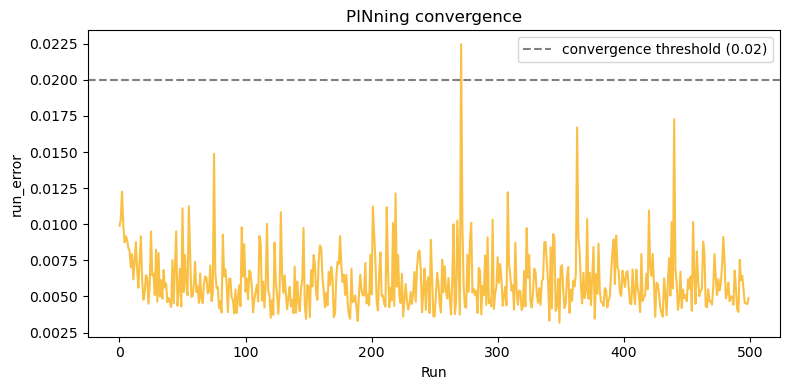

In [12]:
rnn = RNN(N, g, dt, tau, theta, p0)
PINned_model = PINning(p, rnn, targets, p0)
errors, j_norms = PINned_model.train(inputs, n_runs, cv_threshold, DEBUG = True, p_reg=p_reg)
PINned_model.display_cv(errors)

In [13]:
final_rates = PINned_model.simulate(inputs, n_steps=n_steps)

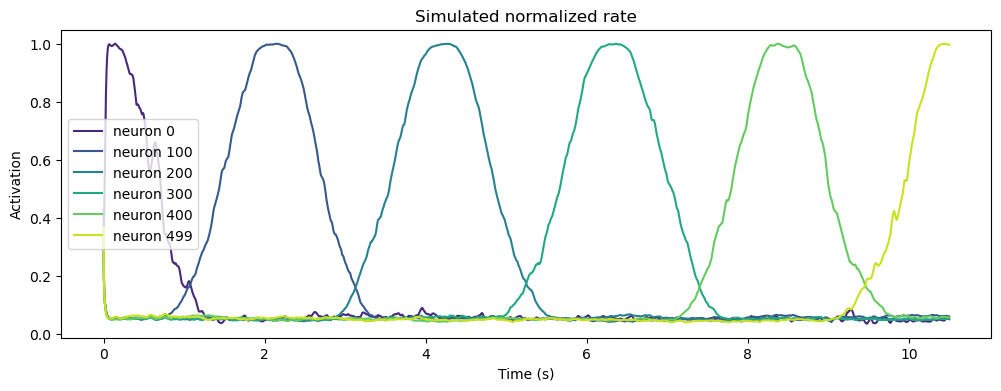

In [14]:
neuron_list = [0, 100, 200, 300, 400, 499]
PINned_model.display_simulation(T, dt, final_rates, neuron_list)

## Evaluation

In [9]:
threshold = 0.95

In [9]:
from src.evaluation import Metrics

In [17]:
from scipy.special import expit
targets_rate = expit(targets)
Metrics.general_evaluation(rates = final_rates, targets = targets_rate, t = gs.t, sigma = sigma, threshold = threshold)

,,bVar,pVar,Qeff
0,Model's metrics,0.784936,0.99348,9
1,Article's metrics for p=0.08,1,0.92,10


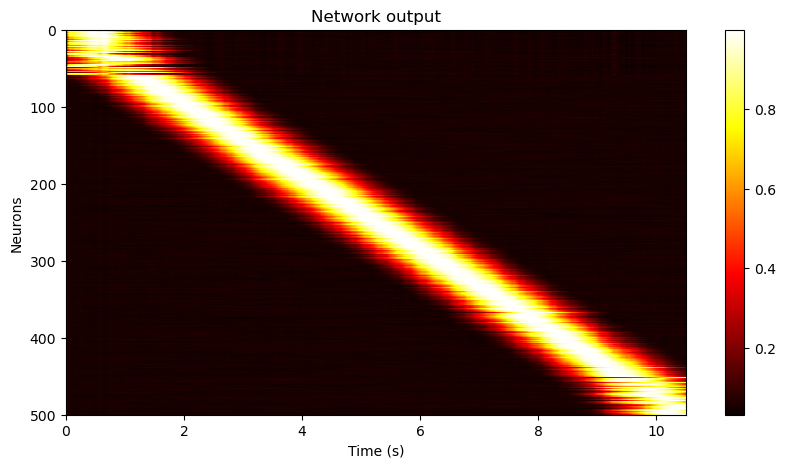

In [18]:
Metrics.network_output(final_rates, T, dt)

## Model saving

In [19]:
from datetime import datetime
model_path = f'model_{datetime.now().strftime("%Y%m%d_%H%M%S")}.npz'

In [20]:
PINned_model.save(model_path)

## Synaptic strength distribution

In [16]:
from src.training import PINning

In [17]:
model, inputs = PINning.load(model_path)

NameError: name 'model_path' is not defined

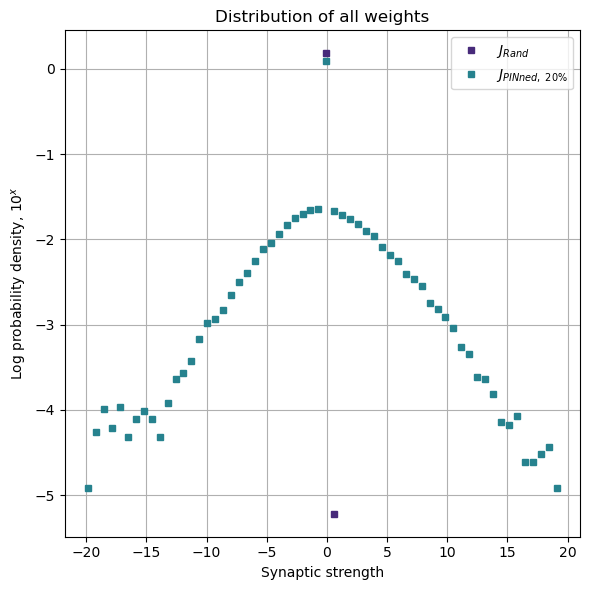

In [23]:
model.display_weight_distribution(value = 'all', bins=60)

# PINning constrained by Dale's principle

In [10]:
from src.training import Dale_PINning, RNN

In [11]:
p = 0.2
n_runs = 1500
p_exc = 0.2
lam = 0
eta = 1e-3
eta_decay = 0.01

rnn = RNN(N, g, dt, tau, theta, p0)
dale_model = Dale_PINning(p, rnn, targets, p0)

Run 1/1500 | run_error=0.412288 | ||J||=81.05
Run 2/1500 | run_error=0.517128 | ||J||=95.06
Run 3/1500 | run_error=0.467227 | ||J||=100.41
Run 4/1500 | run_error=0.287759 | ||J||=103.09
Run 5/1500 | run_error=0.233987 | ||J||=104.28
Run 6/1500 | run_error=0.195076 | ||J||=105.63
Run 7/1500 | run_error=0.175524 | ||J||=107.83
Run 8/1500 | run_error=0.175390 | ||J||=109.35
Run 9/1500 | run_error=0.164070 | ||J||=110.50
Run 10/1500 | run_error=0.162673 | ||J||=111.37
Run 11/1500 | run_error=0.157505 | ||J||=112.35
Run 12/1500 | run_error=0.158827 | ||J||=113.28
Run 13/1500 | run_error=0.157456 | ||J||=114.23
Run 14/1500 | run_error=0.157397 | ||J||=115.13
Run 15/1500 | run_error=0.156219 | ||J||=115.97
Run 16/1500 | run_error=0.154644 | ||J||=116.76
Run 17/1500 | run_error=0.153545 | ||J||=117.53
Run 18/1500 | run_error=0.151953 | ||J||=118.28
Run 19/1500 | run_error=0.150907 | ||J||=118.97
Run 20/1500 | run_error=0.150371 | ||J||=119.62
Run 21/1500 | run_error=0.149759 | ||J||=120.23
Run

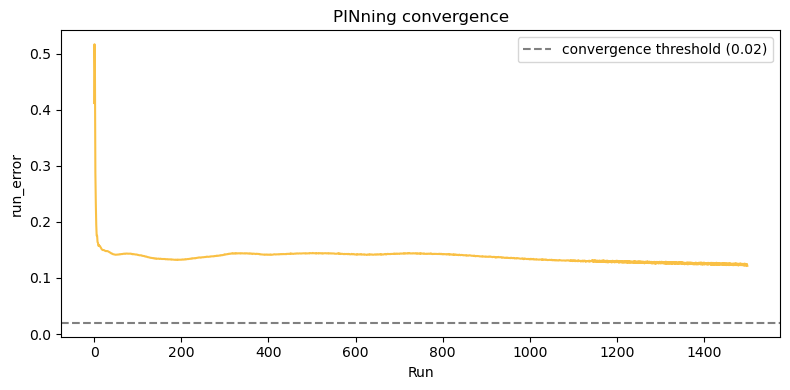

In [12]:
dale_model.set_dale_constraint(p_exc)
errors, j_norms = dale_model.train_dale_pgd(inputs, n_runs, eta, cv_threshold, lam, eta_decay, DEBUG=True)
dale_model.display_cv(errors)

In [13]:
final_rates = dale_model.simulate(inputs, n_steps=n_steps)

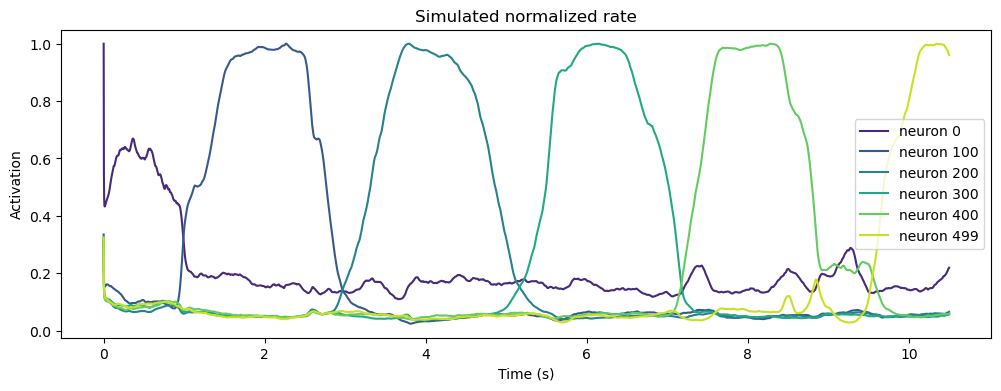

In [20]:
neuron_list = [0, 100, 200, 300, 400, 499]
dale_model.display_simulation(T, dt, final_rates, neuron_list)

In [17]:
from datetime import datetime
model_path = f'dale_model_{datetime.now().strftime("%Y%m%d_%H%M%S")}.npz'
dale_model.save(model_path)